# Réseaux de neuronnes

Un réseau de neurones est un modèle d’apprentissage automatique inspiré du fonctionnement du cerveau humain. Il est composé de couches de neurones artificiels qui transforment progressivement les données d’entrée pour produire une prédiction. Chaque neurone applique une combinaison linéaire des variables suivie d’une fonction non linéaire, ce qui permet au modèle de capturer des relations complexes entre les données.

Dans le cadre de ce projet, les réseaux de neurones peuvent être particulièrement intéressants car ils sont capables de modéliser des dynamiques non linéaires et des interactions complexes entre les variables, notamment dans des séries temporelles comme les données hydrologiques ou météorologiques. Contrairement aux méthodes d’interpolation classiques ou aux approches comme le KNN, ils peuvent apprendre des motifs plus globaux et exploiter simultanément plusieurs variables explicatives. Cela peut permettre d’obtenir des imputations plus précises, en particulier lorsque les données présentent des comportements complexes ou peu réguliers.

## Imports & Variables

In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))

from src.methodes import *
from src.visualisations import *
from src.data import *

from keras.models import load_model


In [18]:
valeur_de_travail = 'niveau_nappe_eau'
window_size = 60

racine = "../../../"

# fichier_nappe = racine + "data/fusion/data_03288X0042_P.csv"
fichier_nappe = racine + "data/fusion/data_03276X0009_P.csv"
dossier_nappe = racine + "data/fusion"

dossier_model = racine + "models/"

fichier_scaler = racine + "scaler/scaler.save"

df = charger_fichier(fichier_nappe)

## Préparation des données

In [19]:
X_train, X_val, y_train, y_val, scaler = train_data(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=False)

## CNN

Un réseau de neurones convolutif (CNN) est un modèle conçu pour extraire automatiquement des motifs locaux dans les données à l’aide de filtres de convolution. Bien qu’il soit souvent utilisé pour les images, il peut également être appliqué à des séries temporelles. Dans ce cas, le CNN permet de détecter des patterns locaux, comme des variations rapides ou des structures répétitives dans les données. Dans ce projet, il peut être utile pour capter des comportements locaux dans les séries temporelles et améliorer l’imputation en identifiant des tendances fines difficiles à modéliser avec des méthodes classiques.

In [20]:
cnn(X_train, y_train, X_val, y_val, dossier_model)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 53s 163ms/step - loss: 0.0687 - val_loss: 0.0333
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - loss: 0.0330 - val_loss: 0.0261
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 54s 167ms/step - loss: 0.0275 - val_loss: 0.0208
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - loss: 0.0228 - val_loss: 0.0190
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 54s 165ms/step - loss: 0.0209 - val_loss: 0.0176
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 52s 160ms/step - loss: 0.0199 - val_loss: 0.0179
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - loss: 0.0193 - val_loss: 0.0161
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 54s 168ms/step - loss: 0.0184 - val_loss: 0.0158
Epoch 9/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 78s 241ms/step - loss: 0.0175 - val_loss: 0.0156
Epoch 10/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 53s 162ms/step - loss: 0.0168 - val_loss: 0.0144
Epoch 11/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 54s 167ms/step - loss: 0.0163 - val_loss: 0.0143
Epoch 12/50
324/324

## LSTM

Le LSTM est un type de réseau de neurones récurrent (RNN) spécialement conçu pour traiter des données séquentielles. Il est capable de mémoriser des informations sur de longues périodes grâce à un mécanisme de mémoire interne. Cela le rend particulièrement adapté aux séries temporelles, où les valeurs passées influencent les valeurs futures. Dans ce projet, le LSTM permet de modéliser les dépendances temporelles et les dynamiques à long terme des données, ce qui est essentiel pour reconstruire des valeurs manquantes de manière cohérente dans le temps.

In [13]:
lstm(X_train, y_train, X_val, y_val, dossier_model)

Epoch 1/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - loss: 0.1097 - val_loss: 0.0469
Epoch 2/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 39s 95ms/step - loss: 0.0497 - val_loss: 0.0359
Epoch 3/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - loss: 0.0431 - val_loss: 0.0337
Epoch 4/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - loss: 0.0397 - val_loss: 0.0306
Epoch 5/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - loss: 0.0375 - val_loss: 0.0303
Epoch 6/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - loss: 0.0364 - val_loss: 0.0289
Epoch 7/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - loss: 0.0354 - val_loss: 0.0282
Epoch 8/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - loss: 0.0347 - val_loss: 0.0281
Epoch 9/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - loss: 0.0339 - val_loss: 0.0275
Epoch 10/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - loss: 0.0333 - val_loss: 0.0271
Epoch 11/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - loss: 0.0327 - val_loss: 0.0268
Epoch 12/50
405/405 ━━━━━━━━

## BILSTM

Le BiLSTM est une extension du LSTM qui traite les données dans les deux sens : du passé vers le futur, mais aussi du futur vers le passé. Cela permet au modèle de prendre en compte l’ensemble du contexte temporel pour chaque point. Dans le cadre de l’imputation de données, cela est particulièrement intéressant car la valeur manquante peut dépendre à la fois des observations précédentes et suivantes. Le BiLSTM permet ainsi d’obtenir des reconstructions souvent plus précises, en exploitant davantage d’information que les modèles unidirectionnels.

In [14]:
bilstm(X_train, y_train, X_val, y_val, dossier_model)

Epoch 1/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - loss: 0.0885 - val_loss: 0.0387
Epoch 2/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - loss: 0.0434 - val_loss: 0.0333
Epoch 3/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - loss: 0.0392 - val_loss: 0.0314
Epoch 4/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - loss: 0.0371 - val_loss: 0.0294
Epoch 5/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 55s 135ms/step - loss: 0.0353 - val_loss: 0.0291
Epoch 6/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 55s 135ms/step - loss: 0.0344 - val_loss: 0.0278
Epoch 7/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step - loss: 0.0335 - val_loss: 0.0280
Epoch 8/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - loss: 0.0335 - val_loss: 0.0277
Epoch 9/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 55s 137ms/step - loss: 0.0322 - val_loss: 0.0269
Epoch 10/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 68s 168ms/step - loss: 0.0318 - val_loss: 0.0267
Epoch 11/50
405/405 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - loss: 0.0311 - val_loss: 0.0266
Epoch 12/50
405/405

Chargement des modèles...


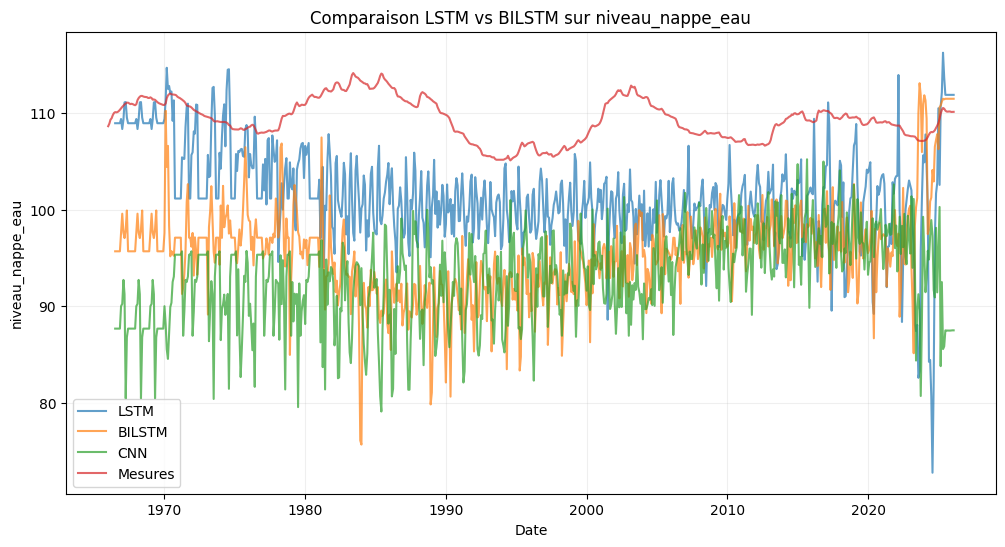

In [21]:
features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

# 2. Chargement des modèles avec la perte masquée
print("Chargement des modèles...")

valeur_de_travail = "niveau_nappe_eau"

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=False)

custom_objs = {'masked_mse': masked_mse}
model_cnn = load_model(dossier_model + "CNN.keras", custom_objects={'masked_mse': masked_mse})
model_bilstm = load_model(dossier_model + "BILSTM.keras", custom_objects={'masked_mse': masked_mse})
model_lstm = load_model(dossier_model + "LSTM.keras", custom_objects={'masked_mse': masked_mse})

mon_scaler = joblib.load(fichier_scaler)
arr_lstm = lstm_predict_array(df, model_lstm, mon_scaler, features, window_size=6, target_col=valeur_de_travail)
arr_bilstm = lstm_predict_array(df, model_bilstm, mon_scaler, features, window_size=6, target_col=valeur_de_travail)
arr_cnn = lstm_predict_array(df, model_cnn, mon_scaler, features, window_size=6, target_col=valeur_de_travail)

methods = {
    "LSTM": arr_lstm,
    "BILSTM": arr_bilstm,
    "CNN": arr_cnn,
    "Mesures": df[valeur_de_travail],
}

# 5. Graphique
plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'], arr, label=label, alpha=0.7)

plt.title(f"Comparaison LSTM vs BILSTM sur {valeur_de_travail}")
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()